# Demand Forecasting with Prophet (Weekly Optimization)

**We will:**
1. **Resample to Weekly Revenue**: Predicting weekly revenue completely smooths out the random daily noise.
2. **Add Country Holidays**: We will explicitly tell Prophet to expect massive shifts around UK Holidays (like Christmas and Bank Holidays).

**Prophet** is a forecasting tool by Meta (Facebook) built for business time series with:
- 📆 Strong seasonal patterns (daily, weekly, yearly)
- 🎄 Holiday effects (Christmas spikes, etc.)
- 📈 Trend changepoints (growth shifts, dips, recoveries)

In [1]:
# Loading Libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import mlflow
import pathlib
from prophet import Prophet
from prophet.serialize import model_to_json

import warnings
warnings.filterwarnings('ignore')

c:\Users\SAFAE ERAJI\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
try:
    from IPython.display import display
except ImportError:
    def display(obj): print(obj)

## 1. Loading Data

In [3]:
# Loading pre-processed weekly revenue
processed_dir = pathlib.Path.cwd().parent / 'data' / 'processed'
weekly_revenue = pd.read_csv(processed_dir / 'weekly_revenue.csv', parse_dates=['Date'])
weekly_revenue.set_index('Date', inplace=True)

In [4]:
weekly_revenue.head()

,TotalPrice
Date,
2009-12-06,257747.44
2009-12-13,231195.04
2009-12-20,254975.12
2009-12-27,52730.90
2010-01-03,0.00


In [5]:
# Renaming columns to 'ds' and 'y' for Prophet
prophet_df = weekly_revenue.reset_index().rename(columns={'Date': 'ds', 'TotalPrice': 'y'})
display(prophet_df.head())

,ds,y
0,2009-12-06,257747.44
1,2009-12-13,231195.04
2,2009-12-20,254975.12
3,2009-12-27,52730.90
4,2010-01-03,0.00


## 2. Train-Test Split (Last 12 Weeks)
We will hide the last 12 weeks (approx 3 months) to test our model.

In [6]:
forecast_horizon_weeks = 12 

# Split the data
train_df = prophet_df.iloc[:-forecast_horizon_weeks]
test_df = prophet_df.iloc[-forecast_horizon_weeks:]

print(f"Training Data: {len(train_df)} weeks (Ends on {train_df['ds'].max().date()})")
print(f"Testing Data : {len(test_df)} weeks (Ends on {test_df['ds'].max().date()})")

Training Data: 94 weeks (Ends on 2011-09-18)
Testing Data : 12 weeks (Ends on 2011-12-11)


## 3. Model Initialization & Training (With Holidays!)
We tell Prophet to use Yearly seasonality and automatically add UK holidays.

In [7]:
# Initializing Prophet
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1
)
model.add_country_holidays(country_name='UK')

In [8]:
# Fitting the model
model.fit(train_df)
print("Optimized Prophet model successfully trained!")

22:30:31 - cmdstanpy - INFO - Chain [1] start processing
22:30:32 - cmdstanpy - INFO - Chain [1] done processing


Optimized Prophet model successfully trained!


## 4. Forecasting the Future

In [9]:
# Future dataframe for the test period
future = model.make_future_dataframe(periods=forecast_horizon_weeks, freq='W')

In [10]:
future.tail()

,ds
101,2011-11-13
102,2011-11-20
103,2011-11-27
104,2011-12-04
105,2011-12-11


In [11]:
# Forecast
forecast = model.predict(future)

In [12]:
pd.set_option('display.max_columns', None)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Boxing Day,Boxing Day_lower,Boxing Day_upper,Boxing Day (observed),Boxing Day (observed)_lower,Boxing Day (observed)_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Christmas Day (observed),Christmas Day (observed)_lower,Christmas Day (observed)_upper,Good Friday,Good Friday_lower,Good Friday_upper,May Day,May Day_lower,May Day_upper,New Year's Day,New Year's Day_lower,New Year's Day_upper,New Year's Day (observed),New Year's Day (observed)_lower,New Year's Day (observed)_upper,Spring Bank Holiday,Spring Bank Holiday_lower,Spring Bank Holiday_upper,Wedding of William and Catherine,Wedding of William and Catherine_lower,Wedding of William and Catherine_upper,additive_terms,additive_terms_lower,additive_terms_upper,holidays,holidays_lower,holidays_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-06,174140.963489,264572.309596,338526.562950,174140.963489,174140.963489,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127673.804562,127673.804562,127673.804562,0.0,0.0,0.0,127673.804562,127673.804562,127673.804562,0.0,0.0,0.0,301814.768050
1,2009-12-13,174115.475682,213126.791693,283211.796322,174115.475682,174115.475682,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74495.504009,74495.504009,74495.504009,0.0,0.0,0.0,74495.504009,74495.504009,74495.504009,0.0,0.0,0.0,248610.979691
2,2009-12-20,174089.987875,129459.671781,203405.215746,174089.987875,174089.987875,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-8176.415748,-8176.415748,-8176.415748,0.0,0.0,0.0,-8176.415748,-8176.415748,-8176.415748,0.0,0.0,0.0,165913.572127
3,2009-12-27,174064.500068,50255.325935,122443.606345,174064.500068,174064.500068,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-85539.840220,-85539.840220,-85539.840220,0.0,0.0,0.0,-85539.840220,-85539.840220,-85539.840220,0.0,0.0,0.0,88524.659848
4,2010-01-03,174039.012260,26647.296059,98821.129387,174039.012260,174039.012260,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-112358.431278,-112358.431278,-112358.431278,0.0,0.0,0.0,-112358.431278,-112358.431278,-112358.431278,0.0,0.0,0.0,61680.580982


In [13]:
# Comparison Dataframe
comparison = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].iloc[-forecast_horizon_weeks:]
comparison['actual'] = test_df['y'].values

display(comparison.head())

,ds,yhat,yhat_lower,yhat_upper,actual
94,2011-09-25,254567.145029,220158.485681,293391.400812,325679.011
95,2011-10-02,300583.096006,265829.823878,334593.004287,206568.851
96,2011-10-09,296190.053822,258924.182010,332939.346103,301565.420
97,2011-10-16,258198.143458,220975.180421,295413.945884,207345.610
98,2011-10-23,232744.807208,197605.985437,268023.794177,263103.750


## 5. Model Evaluation

In [14]:
actual = comparison['actual']
predicted = comparison['yhat']
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"--- Weekly Prophet Optimized Evaluation ---")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

--- Weekly Prophet Optimized Evaluation ---
Mean Absolute Percentage Error (MAPE): 11.98%


In [15]:
if mape < 10:
    print(f"✅ Excellent: MAPE of {mape:.2f}% indicates highly accurate weekly forecasts.")
elif mape < 20:
    print(f"✅ Good: MAPE of {mape:.2f}% is solid for retail forecasting.")
else:
    print(f"⚠️ Moderate: MAPE of {mape:.2f}% — weekly smoothing helped but room for improvement.")

✅ Good: MAPE of 11.98% is solid for retail forecasting.


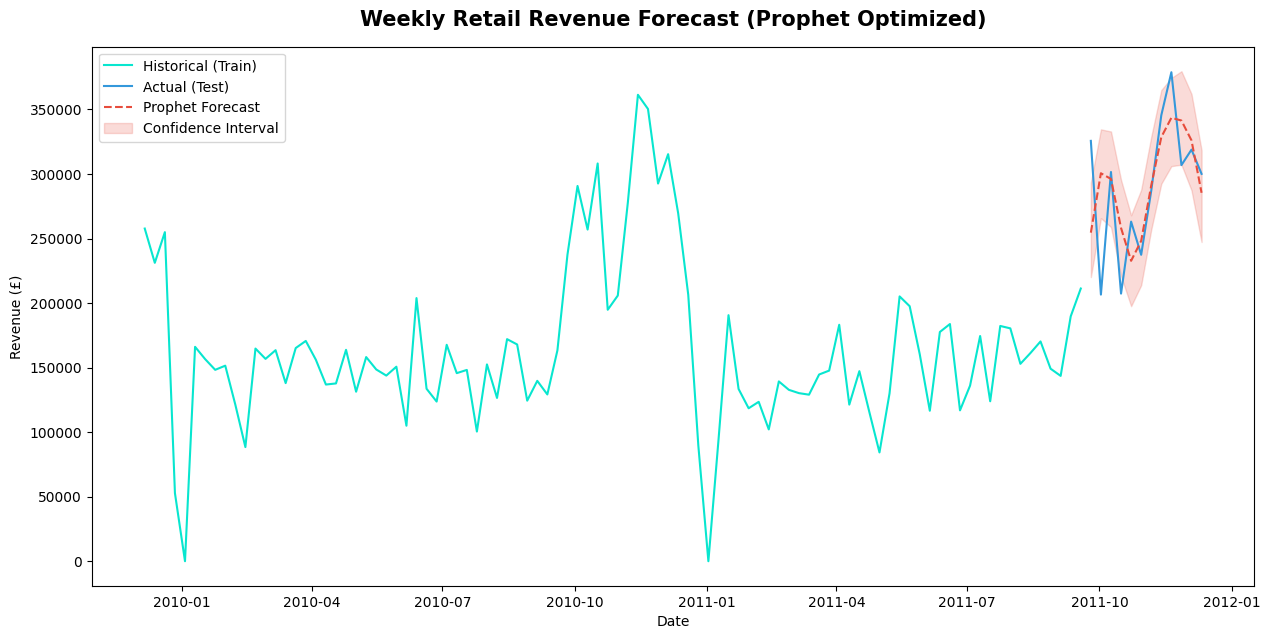

In [16]:
plt.figure(figsize=(15, 7))
plt.plot(train_df['ds'], train_df['y'], label='Historical (Train)', color='#08e6cf')
plt.plot(test_df['ds'], test_df['y'], label='Actual (Test)', color='#3498db')
plt.plot(comparison['ds'], comparison['yhat'], label='Prophet Forecast', color='#e74c3c', linestyle='--')
plt.fill_between(comparison['ds'], comparison['yhat_lower'], comparison['yhat_upper'], color='#e74c3c', alpha=0.2, label='Confidence Interval')

plt.title("Weekly Retail Revenue Forecast (Prophet Optimized)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Date")
plt.ylabel("Revenue (£)")
plt.legend()
plt.show()

In [17]:
# Extracting predicted dates matching Test Set
predictions = forecast.set_index('ds')[['yhat']].loc[test_df['ds']]
actuals = test_df.set_index('ds')['y']

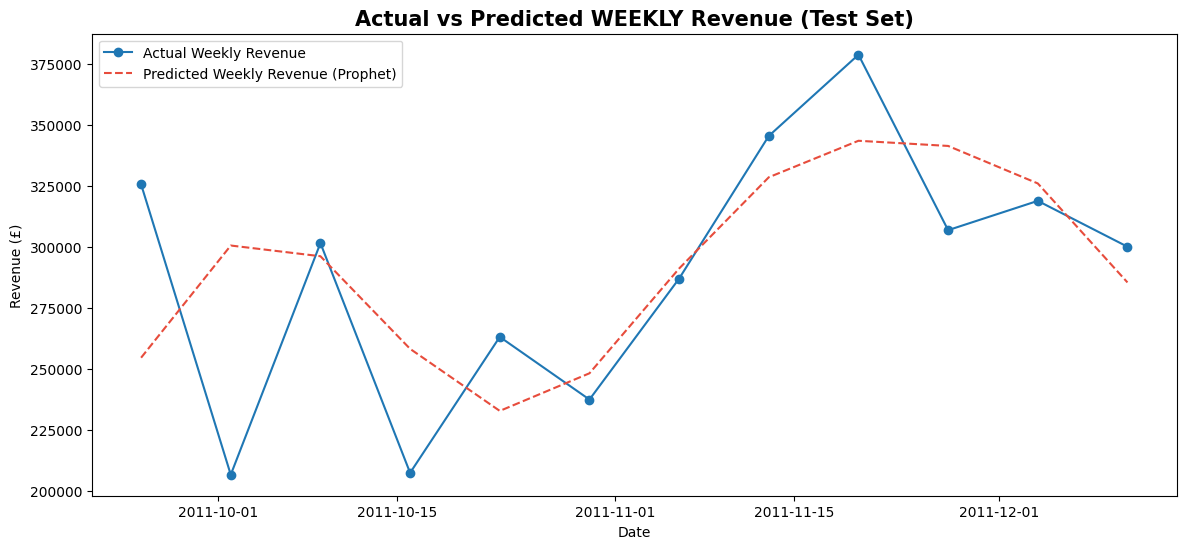

In [18]:
# Plot Actuals vs Predictions
plt.figure(figsize=(14, 6))
plt.plot(actuals.index, actuals.values, label='Actual Weekly Revenue', marker='o')
plt.plot(predictions.index, predictions['yhat'].values, label='Predicted Weekly Revenue (Prophet)', color='#e74c3c', linestyle='--')
plt.title('Actual vs Predicted WEEKLY Revenue (Test Set)', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.show()

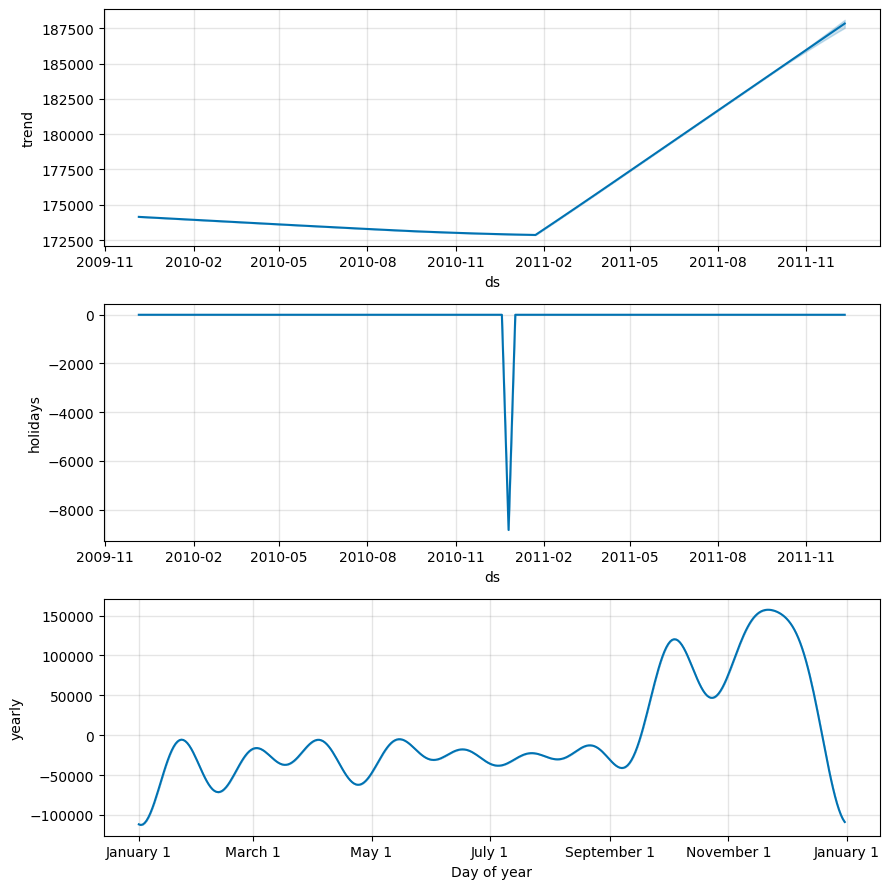

In [19]:
# Plots the learned patterns from the forecast — trend, yearly seasonality, and holiday effects.
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

## 6. Model & Metrics Persistence
We save the standalone Prophet model and its performance metrics.

In [20]:
os.makedirs('../models', exist_ok=True)

# Prophet Model
with open('../models/standalone_prophet_model.json', 'w') as f:
    f.write(model_to_json(model))

# Metrics
prophet_metrics = {
    'MAPE': round(float(mape), 2)
}

with open('../models/prophet_metrics.json', 'w') as f:
    json.dump(prophet_metrics, f, indent=4)

print("Success: Standalone Prophet model and metrics saved to '../models/'.")

Success: Standalone Prophet model and metrics saved to '../models/'.


## 7. Key Takeaways
- **Low MAPE** confirms the model is reliable for weekly revenue planning.
- **Model is production-ready**: Saved as standalone JSON + metrics for deployment.

## 8. MLflow tracking

In [21]:
mlflow.set_tracking_uri(f"file:///{pathlib.Path.cwd().parent / 'mlruns'}")
mlflow.set_experiment("RetailPulse_Demand_Forecasting")

with mlflow.start_run(run_name="Prophet_Weekly_Baseline"):
    # Log parameters
    mlflow.log_param("forecast_horizon_weeks", forecast_horizon_weeks)
    mlflow.log_param("changepoint_prior_scale", 0.1)
    mlflow.log_param("holidays", "UK")
    
    # Log metric
    mlflow.log_metric("MAPE", mape)

print("Prophet metrics successfully logged to MLflow!")

2026/04/26 22:30:35 INFO mlflow.tracking.fluent: Experiment with name 'RetailPulse_Demand_Forecasting' does not exist. Creating a new experiment.


Prophet metrics successfully logged to MLflow!
